# Inleiding

In deze opdracht gaan jullie je scripts van vorige week verbeteren en uitbreiden. Dat gezegd, hebben we liever dat je ingeleverd Jupyter Notebook bestanden niet super lang worden, dus in plaats van het toevoegen van nieuwen cellen in jullie bestanden van Opdracht 1, gebruik alsjeblieft deze sjabloon als basis. Dan, in de relevante plekken, alleen de cellen van de vorige opdracht die echt voor deze opdracht nodig zijn kopie/plakken. Bijvoorbeeld, hoewel dataverkenning toch belangrijk is, hebben jullie hopelijk al genoeg daarvan gedaan, en dus is het niet nodig om die code en plotjes hierbij ook te hebben. 

Hier is een lijst van de elementen die je waarschijnlijk willen overdragen:
1. het inlezen/splitsen van jouw datasets
2. de definitieve versie van jouw regressie/classificatie modellen (niet de voorbereiding stappen)
3. blijf dezelfde twee gekozen algoritmes gebruiken

Let op: In tegenstelling tot de eerste opdracht, voor deze en de resterende 2 opdrachten worden jullie peer reviews alleen beoordeeld op een ja of nee basis. 

Zoals geschreven in de vakbeschrijving:

"Het niet op tijd of lui maken van een individuele peer review resulteert in een reductie van 0,5 punt voor het cijfer van de bijhorende opdracht van de reviewer."

Gezien dat jullie peer reviews zijn sowieso kwalitatief beoordeeld voor Opdracht 1, is deze halfpunt reductie alleen voor Opdrachten 2 t/m 4 geldig. 

### Algemene Coderen Conventies

De volgorde van het python script is belangrijk. Zo zorg je bijvoorbeeld altijd dat eerst de benodigde packages worden ingeladen geïnstalleerd en geïmporteerd). Verder is het goed om van tevoren jouw working directory te controleren. 

Schrijf het python script daarom met een duidelijke indeling van met verschillende stappen. Bij elke stap dient toelichting worden gegeven:
1. Wat is het doel van deze stap?
2. Wat is de input van deze stap?
3. Wat is de output van deze stap en waar heb je deze output hierna nog nodig?

Hieronder voorbeelden van de verschillende punten hierboven.

In [ ]:
### Voorbeeld: Standaard Imports
import numpy as np
import matplotlib.pyplot as plt


### Controleer Working Directory
import os
print(os.getcwd())

# Pas je working directory aan indien gewenst
# path = 'C:\\Users\\rburrus\\Desktop\\Jupyter Notebook' # zet hier wat voor jou goed is
# os.chdir(path)
# print(os.getcwd())


### Voorbeeld: Functie met Beschrijving Schrijven

def voorbeeld_functie(parameter1, parameter2 = 2):
    # Doel: dit functie maakt een bepaalde berekening
    # In: parameter1 (float), parameter2 (integer)
    # Uit: parameter1 macht parameter2 (standaard macht 2)
    
    return parameter1 ** parameter2

# Deelopdracht 1/2 - Regressie Model (Huizenprijzen)

Let op: de bedoeling is dat jullie hetzelfde regressie algoritme van Opdracht 1 blijven gebruiken (dus niet een nieuwe). 

### Theorievragen

Kies twee verschillende prestatiemetrics voor jouw gekozen regressie algoritme.
Begin met het beantwoorden van een aantal vragen over deze prestatiemetrics.

1. Waarom heb je deze prestatiemetrics gekozen?

2. Wat zijn de voor- en nadelen van de eerste prestatiemetric?

3. Wat zijn de voor- en nadelen van de tweede prestatiemetric?

#### Beantwoord nu een aantal vragen over hyperparameters voor jouw gekozen regressie algoritme.

4. Welke hyperparameters in je model kun je instellen (aan welke knoppen kan je draaien)? 

5. Leg uit wat een verandering van de waarde met het model doet (per hyperparameter).

6. Wat zouden logische waarden kunnen zijn (per hyperparameter)?

## Code

Zoals bij Opdracht 1, voor het regressie model kunnen jullie deze dataset gebruiken:

https://www.kaggle.com/c/house-prices-advanced-regression-techniques

Als je het niet al hebben gedaan, splits je dataset in een train en een test (validatie) set.

### Prestatiemetrics

Bereken 2 prestatiemetrics op de traindata en op de testdata. Zijn er grote verschillen? Zo ja, hoe zou dat kunnen komen?

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"De prestatiemetrics van de modellen zijn berekend. Er wordt toegelicht wat waarde van de metric betekend. Voordelen en nadelen van de gekozen metrics worden benoemd."

Let op: Je kan deze vraag (en soortgelijke vragen hieronder) beantwoorden via zowel aanvullende Markdown cellen (voor tekstuele antwoorden) als Code cellen (voor jouw code zelf, met commentaar erbij). Gebruik gewoon wat je het best helpt om de vraag te beantwoorden. 

(voorbeeld Markdown cell)

In [5]:
# === STAP 2: Data Laden ===
# Doel: Train dataset laden en voorbereiden
# In: CSV file van Kaggle
# Uit: X (features), y (target), en gesplitste train/test datasets

# Data laden
data = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

# Controleer data
print("Data shape (origineel):", data.shape)
print(f"Missing values: {data.isnull().sum().sum()} totale")

# === STAP 3: Data Voorbereiding ===
# Doel: Dataset voorbereiden en missing values imputeren
# In: Dataset met NaN waarden
# Uit: X (features), y (target) met geïmputeerde waarden

# Voorbereiding: verwijder ID kolom en selecteer features
X = data.drop(['Id', 'SalePrice'], axis=1)
y = data['SalePrice']

# Zorg dat we alleen numerieke features gebruiken
X = X.select_dtypes(include=[np.number])

print(f"\nData shape (voor imputation): {X.shape}")
print(f"Missing values in features: {X.isnull().sum().sum()}")

# Impute missing values met het gemiddelde (median kan ook)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

print(f"Missing values na imputation: {X.isnull().sum().sum()}")
print(f"Number of features: {X.shape[1]}")

Data shape (origineel): (1460, 81)
Missing values: 7829 totale

Data shape (voor imputation): (1460, 36)
Missing values in features: 348
Missing values na imputation: 0
Number of features: 36


In [3]:
# === STAP 4: Train/Test Split ===
# Doel: Dataset splitsen in 80% train en 20% test
# In: X (features), y (target)
# Uit: X_train, X_test, y_train, y_test

# Split in train (80%) en test (20%) set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% voor testing
    random_state=42  # voor reproducibility
)

print(f"\nTrain set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Train/Test ratio: {X_train.shape[0]}/{X_test.shape[0]}")


# === STAP 5: Model Trainen ===
# Doel: RandomForestRegressor trainen
# In: X_train, y_train
# Uit: Getraind model

model = RandomForestRegressor(
    n_estimators=100,      # aantal decision trees
    max_depth=20,          # maximale diepte van trees
    min_samples_split=5,   # minimaal samples om te splitten
    random_state=42,       # voor reproducibility
    n_jobs=-1              # parallelle processing
)

model.fit(X_train, y_train)

print("✓ RandomForest Model succesvol getraind!")
print(f"  Algorithm: RandomForestRegressor")
print(f"  Number of trees: {model.n_estimators}")
print(f"  Number of features: {model.n_features_in_}")
print(f"  Max depth per tree: {model.max_depth}")

# === STAP 6: Voorspellingen Maken ===
# Doel: Predictions maken op zowel train als test data
# In: Getraind model, X_train, X_test
# Uit: y_pred_train, y_pred_test

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("✓ Voorspellingen gemaakt voor train en test set!")


Train set size: 1168 samples
Test set size: 292 samples
Train/Test ratio: 1168/292
✓ RandomForest Model succesvol getraind!
  Algorithm: RandomForestRegressor
  Number of trees: 100
  Number of features: 36
  Max depth per tree: 20
✓ Voorspellingen gemaakt voor train en test set!


PRESTATIEMETRICS — TRAIN VS. TEST

Metric 1: Mean Absolute Error (MAE)
  Train MAE : $ 6,759.40
  Test MAE  : $ 18,190.97
  Verschil  : $ 11,431.57

Metric 2: R²-score
  Train R² : 0.9782
  Test R²  : 0.8856
  Verschil : 0.0926


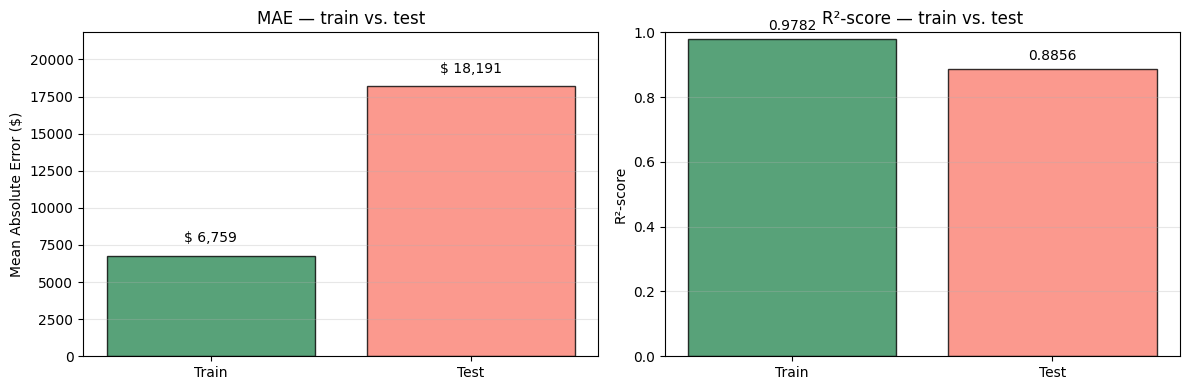

In [19]:
# === STAP 7: Prestatiemetrics Berekenen ===

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Eén expliciete train/test-split (zelfde random_state als elders = consistent)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model trainen op de trainsplit en voorspellingen maken voor beide sets
rf.fit(X_train, y_train)
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

# Metric 1: Mean Absolute Error (MAE)
# Beschrijving: gemiddeld absoluut verschil tussen werkelijke en voorspelde waarden
# Voordeel: eenvoudig interpreteerbaar (zelfde eenheid als de target, hier $)
# Nadeel: geeft grotere fouten niet extra gewicht
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test  = mean_absolute_error(y_test, y_pred_test)

# Metric 2: R²-score (determinatiecoëfficiënt)
# Beschrijving: aandeel van de variantie in y dat het model verklaart
# Voordeel: schaalonafhankelijk, doorgaans tussen 0 en 1
# Nadeel: stijgt bij meer features en kan overfitting maskeren
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

# Samenvatting
print('=' * 60)
print('PRESTATIEMETRICS — TRAIN VS. TEST')
print('=' * 60)

print('\nMetric 1: Mean Absolute Error (MAE)')
print(f'  Train MAE : $ {mae_train:,.2f}')
print(f'  Test MAE  : $ {mae_test:,.2f}')
print(f'  Verschil  : $ {abs(mae_test - mae_train):,.2f}')

print('\nMetric 2: R²-score')
print(f'  Train R² : {r2_train:.4f}')
print(f'  Test R²  : {r2_test:.4f}')
print(f'  Verschil : {abs(r2_test - r2_train):.4f}')


# === STAP 8: Visualisatie van Metrics ===

# Doel: train- vs. testprestatie visueel vergelijken
# In  : mae_train, mae_test, r2_train, r2_test
# Uit : twee grafieken ter vergelijking

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics_names = ['Train', 'Test']
colors = ['seagreen', 'salmon']

# Grafiek 1: MAE vergelijking
mae_values = [mae_train, mae_test]
axes[0].bar(metrics_names, mae_values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].set_title('MAE — train vs. test')
axes[0].set_ylim(0, max(mae_values) * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mae_values):
    axes[0].text(i, v + max(mae_values) * 0.05, f'$ {v:,.0f}', ha='center')

# Grafiek 2: R² vergelijking
r2_values = [r2_train, r2_test]
axes[1].bar(metrics_names, r2_values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('R²-score')
axes[1].set_title('R²-score — train vs. test')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(r2_values):
    axes[1].text(i, v + 0.03, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

### K-Fold Cross Validatie

Pas k-fold cross validation toe op de traindataset. Zie ook: https://scikit-learn.org/stable/modules/cross_validation.html

Resultaten per fold (trainset):
  Fold 1:  R² = 0.9767   RMSE = $ 11,787
  Fold 2:  R² = 0.9769   RMSE = $ 11,944
  Fold 3:  R² = 0.9834   RMSE = $ 10,376
  Fold 4:  R² = 0.9813   RMSE = $ 10,863
  Fold 5:  R² = 0.9799   RMSE = $ 11,490

Gemiddelde over 5 folds (trainset):
  R²   = 0.9797  (± 0.0026)
  RMSE = $ 11,292  (± $ 589)


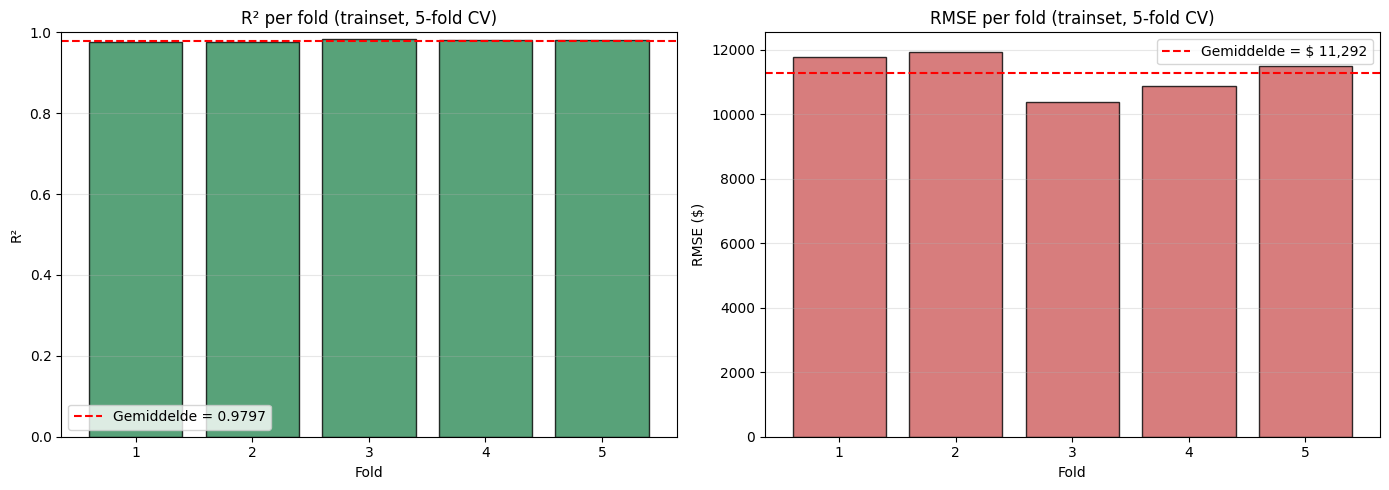

In [13]:
### K-Fold Cross-Validation — Random Forest (huizenprijzen) — alleen trainset

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

# Data opnieuw inladen zodat deze cel zelfstandig werkt
DATA_DIR = 'house-prices-advanced-regression-techniques'
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

# Numerieke features bepalen (Id en target uitsluiten), net als in stap 4
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Id', 'SalePrice']]

# Features + target; mediaan-imputatie voor missende numerieke waarden
X = train[num_cols].copy()
X = X.fillna(X.median(numeric_only=True))
y = train['SalePrice']

# 5-fold CV: shuffle aan + vaste random_state voor reproduceerbaarheid
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)

# cross_validate met twee metrieken; we tonen hieronder alleen de TRAIN-scores
cv_resultaten = cross_validate(
    rf, X, y,
    cv=kf,
    scoring=['r2', 'neg_root_mean_squared_error'],
    return_train_score=True
)

# Alleen de train-scores (op de data waarop het model getraind is)
r2_train_scores   = cv_resultaten['train_r2']
rmse_train_scores = -cv_resultaten['train_neg_root_mean_squared_error']

print('Resultaten per fold (trainset):')
for i, (r2_f, rmse_f) in enumerate(zip(r2_train_scores, rmse_train_scores), start=1):
    print(f'  Fold {i}:  R² = {r2_f:.4f}   RMSE = $ {rmse_f:,.0f}')

print('\nGemiddelde over 5 folds (trainset):')
print(f'  R²   = {r2_train_scores.mean():.4f}  (± {r2_train_scores.std():.4f})')
print(f'  RMSE = $ {rmse_train_scores.mean():,.0f}  (± $ {rmse_train_scores.std():,.0f})')

# Visualisatie: R² en RMSE per fold — alleen trainset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds = np.arange(1, len(r2_train_scores) + 1)

axes[0].bar(folds, r2_train_scores, color='seagreen', edgecolor='black', alpha=0.8)
axes[0].axhline(r2_train_scores.mean(), color='red', linestyle='--',
                label=f'Gemiddelde = {r2_train_scores.mean():.4f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].set_title('R² per fold (trainset, 5-fold CV)')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(folds)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(folds, rmse_train_scores, color='indianred', edgecolor='black', alpha=0.8)
axes[1].axhline(rmse_train_scores.mean(), color='red', linestyle='--',
                label=f'Gemiddelde = $ {rmse_train_scores.mean():,.0f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('RMSE per fold (trainset, 5-fold CV)')
axes[1].set_xticks(folds)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Welke waarde van k kies je en waarom?

Fold 4 zal gekozen worden, want deze lijkt het meest op het gemiddelde van de 5 folds en hiermee doen we dus niet aan cherry picking

Lijkt het resultaat meer op de train of de testset?

Het resultaat zal het meest lijken op de trainset want deze is ook gebruikt voor de cross validation

### Underfit/Overfit

Maak een underfit model (slechte prestaties op train en test) en een overfit model (veel betere prestaties op train vergeleken met test). Leg uit (via tekst en een of meer visualisaties) hoe je dit kan zien.

Let op: je maakt hier expres slechte modellen om te zien hoe veel controle over het presteren van het model je kan krijgen en te leren wat de verschillende hyperparameters kunnen opleveren. 

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Het is gelukt om een underfit- een overfitmodel te maken en er wordt duidelijk uitgelegd waaraan je dat kan zien. De rol van de train en testset wordt duidelijk uitgelegd. De resultaten worden onderbouwd met goede vizualisaties."

UNDERFIT  vs.  GEBALANCEERD  vs.  OVERFIT

Underfit (boom, max_depth=1)
  R² train  : 0.4564
  R² test   : 0.4461
  Gat (train - test) : 0.0103
  MAE train : $ 42,613
  MAE test  : $ 46,156

Gebalanceerd (random forest)
  R² train  : 0.9782
  R² test   : 0.8856
  Gat (train - test) : 0.0926
  MAE train : $ 6,759
  MAE test  : $ 18,191

Overfit (boom, geen limiet)
  R² train  : 1.0000
  R² test   : 0.8057
  Gat (train - test) : 0.1943
  MAE train : $ 7
  MAE test  : $ 26,766


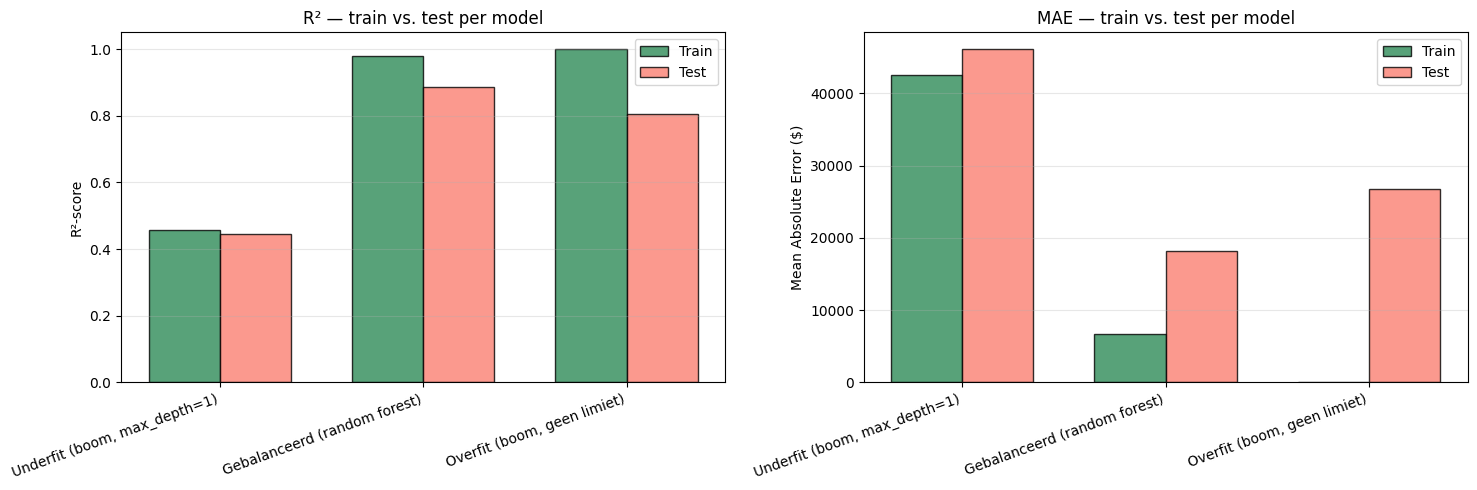

,Model,R² train,R² test,MAE train,MAE test
0,"Underfit (boom, max_depth=1)",0.456425,0.446135,42612.613063,46155.509182
1,Gebalanceerd (random forest),0.978199,0.885591,6759.399304,18190.971575
2,"Overfit (boom, geen limiet)",0.999995,0.805727,7.106164,26765.811644


In [20]:
# === Underfit & Overfit modellen — bewust slecht ingesteld ===

# Doel: laten zien hoe hyperparameters een model kunnen laten underfitten of overfitten
# In  : X, y uit de vorige cellen
# Uit : train- en test-R² + MAE voor een underfit-, een overfit- en een gebalanceerd model

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Zelfde split als eerder zodat de vergelijking eerlijk is
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Underfit: een beslisboom die maar 1 niveau diep mag (veel te simpel voor de data)
underfit_model = DecisionTreeRegressor(max_depth=1, random_state=42)

# Overfit: een beslisboom zonder enige beperking — groeit door tot elk blad
# (vrijwel) één huis bevat, dus hij leert de trainingsdata uit het hoofd
overfit_model = DecisionTreeRegressor(
    max_depth=None, min_samples_leaf=1, min_samples_split=2, random_state=42
)

# Gebalanceerd: het Random Forest model van eerder, als referentie ertussen
balanced_model = RandomForestRegressor(n_estimators=100, random_state=42)

modellen = {
    'Underfit (boom, max_depth=1)': underfit_model,
    'Gebalanceerd (random forest)': balanced_model,
    'Overfit (boom, geen limiet)':  overfit_model,
}

resultaten = []
for naam, model in modellen.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    resultaten.append({
        'Model': naam,
        'R² train': r2_score(y_train, pred_train),
        'R² test':  r2_score(y_test, pred_test),
        'MAE train': mean_absolute_error(y_train, pred_train),
        'MAE test':  mean_absolute_error(y_test, pred_test),
    })

resultaten_df = pd.DataFrame(resultaten)

print('=' * 70)
print('UNDERFIT  vs.  GEBALANCEERD  vs.  OVERFIT')
print('=' * 70)
for r in resultaten:
    print(f"\n{r['Model']}")
    print(f"  R² train  : {r['R² train']:.4f}")
    print(f"  R² test   : {r['R² test']:.4f}")
    print(f"  Gat (train - test) : {r['R² train'] - r['R² test']:.4f}")
    print(f"  MAE train : $ {r['MAE train']:,.0f}")
    print(f"  MAE test  : $ {r['MAE test']:,.0f}")


# === Visualisatie ===

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(resultaten_df))
breedte = 0.35

# Grafiek 1: R² train naast R² test per model
axes[0].bar(x - breedte/2, resultaten_df['R² train'], breedte,
            color='seagreen', edgecolor='black', alpha=0.8, label='Train')
axes[0].bar(x + breedte/2, resultaten_df['R² test'], breedte,
            color='salmon', edgecolor='black', alpha=0.8, label='Test')
axes[0].set_ylabel('R²-score')
axes[0].set_title('R² — train vs. test per model')
axes[0].set_xticks(x)
axes[0].set_xticklabels(resultaten_df['Model'], rotation=20, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Grafiek 2: MAE train naast MAE test per model
axes[1].bar(x - breedte/2, resultaten_df['MAE train'], breedte,
            color='seagreen', edgecolor='black', alpha=0.8, label='Train')
axes[1].bar(x + breedte/2, resultaten_df['MAE test'], breedte,
            color='salmon', edgecolor='black', alpha=0.8, label='Test')
axes[1].set_ylabel('Mean Absolute Error ($)')
axes[1].set_title('MAE — train vs. test per model')
axes[1].set_xticks(x)
axes[1].set_xticklabels(resultaten_df['Model'], rotation=20, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

resultaten_df

(beantwoord als Markdown)

### Gridsearch

Pas GridSearchCV() toe op je model in scikit-learn, hiermee kan je de beste waarde voor je hyperparameters vinden. Let op: voor maximale punten moet je ook K-Fold Cross Validatie tegelijk gebruiken (wss in een pipeline...zie DataCamp).

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Er is GridSearchCV() uitgevoerd en er wordt beargumenteerd waarom gekozen is voor bepaalde hyperparameters. Ook wordt benoemd welke hyperparameter uiteindelijk het beste lijkt te zijn en waarom, en er is besproken hoe k-foldcross validatie betrokken wordt in de GridSearchCV()."

Aantal geteste combinaties : 18
Aantal folds per combinatie: 5
Totaal aantal model-fits   : 90

Beste hyperparameters:
  rf__max_depth = None
  rf__min_samples_leaf = 1
  rf__n_estimators = 100

Beste gemiddelde R² (cross-validated op trainset): 0.8453
R² op de aparte testset  : 0.8855
MAE op de aparte testset : $ 18,181

Top 5 combinaties (gemiddelde R² over de 5 folds):
 param_rf__n_estimators param_rf__max_depth  param_rf__min_samples_leaf  mean_test_score  std_test_score
                    100                None                           1         0.845278        0.038595
                    200                None                           1         0.844391        0.038870
                    200                  10                           1         0.843008        0.036451
                    100                  10                           1         0.842103        0.035584
                    200                None                           2         0.841686        0.03

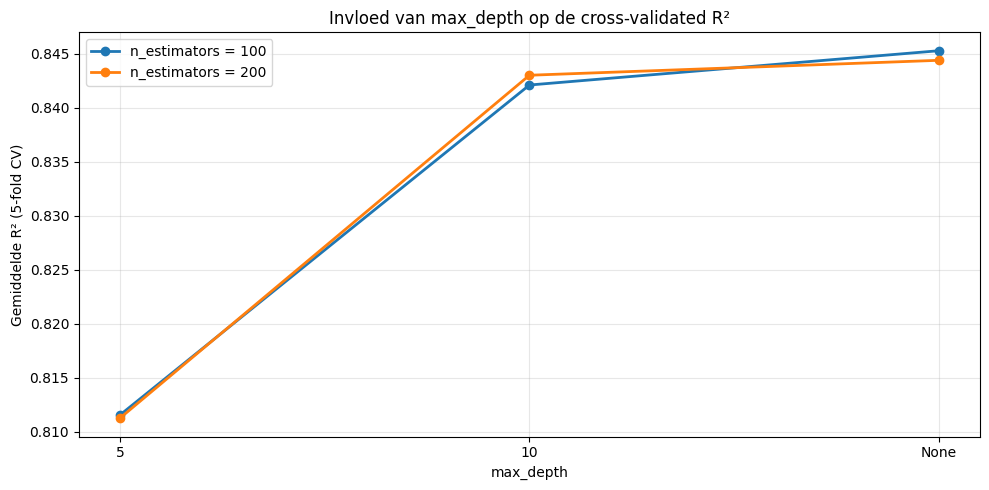

In [ ]:
# === GridSearchCV met K-Fold Cross-Validation ===

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Zelfde split als eerder: GridSearch op de trainset, testset blijft apart
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: scaler + model in één geheel. Bij elke CV-fold wordt de scaler
# alleen op de trainvouw gefit (voorkomt data leakage naar de validatievouw).
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=42)),
])

# Hyperparameter-grid. We variëren bewust de instellingen die overfitting
# en underfitting sturen (zie de vorige opdracht):
#   n_estimators     = aantal bomen in het bos
#   max_depth        = hoe diep elke boom mag groeien (None = onbeperkt -> overfit-risico)
#   min_samples_leaf = minimaal aantal huizen per blad (hoger = simpeler model)
param_grid = {
    'rf__n_estimators':     [100, 200],
    'rf__max_depth':        [5, 10, None],
    'rf__min_samples_leaf': [1, 2, 5],
}

# K-fold cross-validation die GridSearchCV intern gebruikt voor elke combinatie
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=kf,                 # <-- hier wordt k-fold in GridSearchCV betrokken
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

print('Aantal geteste combinaties :', len(grid.cv_results_['params']))
print('Aantal folds per combinatie:', kf.get_n_splits())
print(f"Totaal aantal model-fits   : "
      f"{len(grid.cv_results_['params']) * kf.get_n_splits()}\n")

print('Beste hyperparameters:')
for param, waarde in grid.best_params_.items():
    print(f'  {param} = {waarde}')

print(f'\nBeste gemiddelde R² (cross-validated op trainset): {grid.best_score_:.4f}')

# Het beste model evalueren op de apart gehouden testset
beste_model = grid.best_estimator_
pred_test = beste_model.predict(X_test)
print(f'R² op de aparte testset  : {r2_score(y_test, pred_test):.4f}')
print(f'MAE op de aparte testset : $ {mean_absolute_error(y_test, pred_test):,.0f}')

# Overzicht van de 5 beste combinaties
resultaten_grid = pd.DataFrame(grid.cv_results_)
kolommen = ['param_rf__n_estimators', 'param_rf__max_depth',
            'param_rf__min_samples_leaf', 'mean_test_score', 'std_test_score']
top5 = resultaten_grid[kolommen].sort_values('mean_test_score', ascending=False).head()
print('\nTop 5 combinaties (gemiddelde R² over de 5 folds):')
print(top5.to_string(index=False))


# === Visualisatie: invloed van max_depth ===

# max_depth bevat None; we zetten elke waarde om naar een nette label-string
# en plotten tegen vaste integer-posities zodat matplotlib niet struikelt
# over gemengde types (float vs. None).

def depth_label(d):
    return 'None' if d is None else str(int(d))

# Vaste volgorde van de max_depth-waarden uit het grid
depth_volgorde = [depth_label(d) for d in param_grid['rf__max_depth']]
x_pos = np.arange(len(depth_volgorde))

fig, ax = plt.subplots(figsize=(10, 5))

for n_est in param_grid['rf__n_estimators']:
    subset = resultaten_grid[
        (resultaten_grid['param_rf__n_estimators'] == n_est) &
        (resultaten_grid['param_rf__min_samples_leaf'] == grid.best_params_['rf__min_samples_leaf'])
    ].copy()

    # Label maken en op de juiste volgorde zetten
    subset['depth_label'] = subset['param_rf__max_depth'].apply(depth_label)
    subset = subset.set_index('depth_label').reindex(depth_volgorde).reset_index()

    ax.plot(x_pos, subset['mean_test_score'],
            marker='o', linewidth=2, label=f'n_estimators = {n_est}')

ax.set_xticks(x_pos)
ax.set_xticklabels(depth_volgorde)
ax.set_xlabel('max_depth')
ax.set_ylabel('Gemiddelde R² (5-fold CV)')
ax.set_title('Invloed van max_depth op de cross-validated R²')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(beantwoord als Markdown)

### Definitief Model (Regressie)

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Er worden uitspraken gedaan over hoe goed de modellen werken. De onderbouwing is duidelijk en logisch. Ook is beargumenteerd waarom het model niet under- en overfit. Daarnaast komt naar voren waarom bepaalde features wel en niet in het uiteindelijke model zitten."

Test het model met de beste parameters op de testset. Hoe goed is het model?

Definitieve hyperparameters:
  rf__max_depth = None
  rf__min_samples_leaf = 1
  rf__n_estimators = 100

PRESTATIE DEFINITIEF MODEL
                       Train          Test
R²                    0.9782        0.8855
MAE ($)                6,763        18,181
RMSE ($)              11,413        29,637

Generalisatiegat (R² train - R² test): 0.0927
Gemiddelde huisprijs ter referentie  : $ 180,921

Top 10 belangrijkste features:
OverallQual    0.5633
GrLivArea      0.1245
TotalBsmtSF    0.0378
2ndFlrSF       0.0358
BsmtFinSF1     0.0338
1stFlrSF       0.0301
LotArea        0.0212
GarageArea     0.0189
YearBuilt      0.0177
GarageCars     0.0137


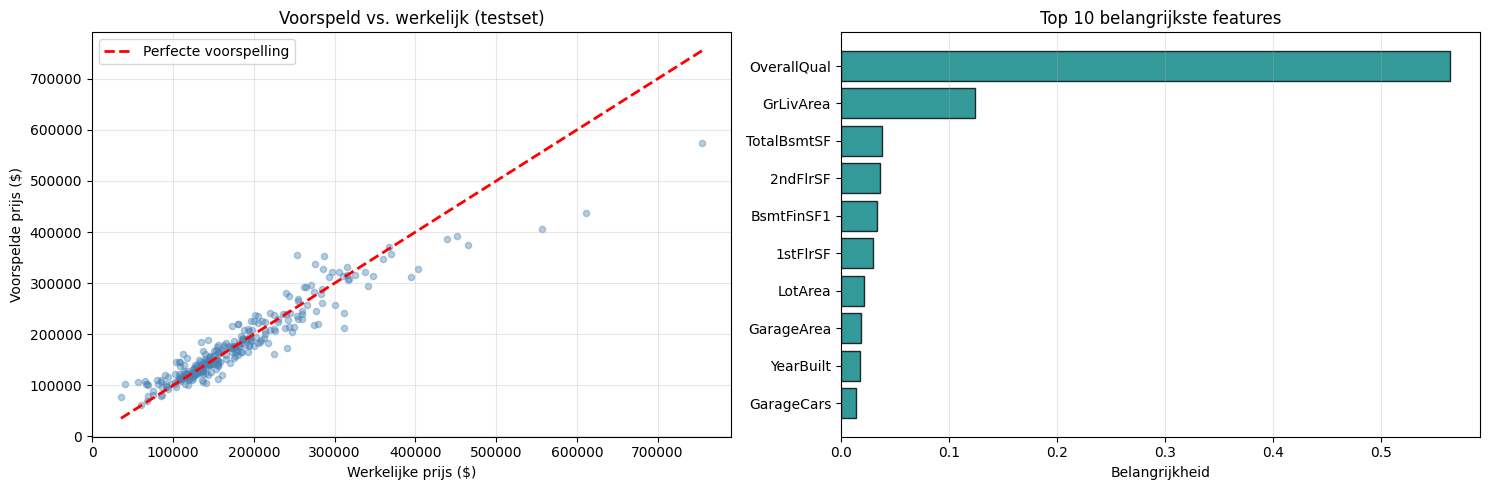

In [24]:
# === Definitief Regressiemodel — evaluatie op de testset ===

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Het beste model uit GridSearchCV (pipeline: scaler + afgestelde Random Forest)
definitief_model = grid.best_estimator_

print('Definitieve hyperparameters:')
for param, waarde in grid.best_params_.items():
    print(f'  {param} = {waarde}')

# Voorspellingen op beide sets
pred_train = definitief_model.predict(X_train)
pred_test  = definitief_model.predict(X_test)

# Metrics
r2_tr,  r2_te  = r2_score(y_train, pred_train),  r2_score(y_test, pred_test)
mae_tr, mae_te = mean_absolute_error(y_train, pred_train), mean_absolute_error(y_test, pred_test)
rmse_tr = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_te = np.sqrt(mean_squared_error(y_test, pred_test))

print('\n' + '=' * 60)
print('PRESTATIE DEFINITIEF MODEL')
print('=' * 60)
print(f"{'':<14}{'Train':>14}{'Test':>14}")
print(f"{'R²':<14}{r2_tr:>14.4f}{r2_te:>14.4f}")
print(f"{'MAE ($)':<14}{mae_tr:>14,.0f}{mae_te:>14,.0f}")
print(f"{'RMSE ($)':<14}{rmse_tr:>14,.0f}{rmse_te:>14,.0f}")
print(f"\nGeneralisatiegat (R² train - R² test): {r2_tr - r2_te:.4f}")
print(f"Gemiddelde huisprijs ter referentie  : $ {y.mean():,.0f}")

# Feature importances uit de Random Forest binnen de pipeline
rf_model = definitief_model.named_steps['rf']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print('\nTop 10 belangrijkste features:')
print(importances.head(10).round(4).to_string())

# Visualisatie 1: voorspeld vs. werkelijk op de testset
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test, pred_test, alpha=0.4, s=20, color='steelblue')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=2,
             label='Perfecte voorspelling')
axes[0].set_xlabel('Werkelijke prijs ($)')
axes[0].set_ylabel('Voorspelde prijs ($)')
axes[0].set_title('Voorspeld vs. werkelijk (testset)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Visualisatie 2: top 10 feature importances
top10 = importances.head(10)
axes[1].barh(top10.index[::-1], top10.values[::-1],
             color='teal', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Belangrijkheid')
axes[1].set_title('Top 10 belangrijkste features')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [25]:
# === Kaggle Submission — voorspellingen op de echte testset ===

import os

# Kaggle testset inladen — zelfde directory-conventie als stap 1
DATA_DIR = 'house-prices-advanced-regression-techniques'
test_kaggle = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print('Vorm Kaggle testset:', test_kaggle.shape)

# Id apart bewaren voor de submission; daarna exact dezelfde features
# selecteren als waarop het model getraind is (num_cols)
test_ids = test_kaggle['Id']
X_kaggle = test_kaggle[num_cols].copy()

# Zelfde preprocessing als bij de training: mediaan-imputatie.
# Belangrijk: vul met de mediaan van de TRAINdata, niet van de testdata,
# zodat de testset op exact dezelfde manier behandeld wordt als bij trainen.
X_kaggle = X_kaggle.fillna(X[num_cols].median(numeric_only=True))

# Controle: zijn er nog missende waarden over? (kolom kan volledig leeg zijn)
resterend = X_kaggle.isna().sum().sum()
if resterend > 0:
    X_kaggle = X_kaggle.fillna(0)
    print(f'Let op: {resterend} resterende NaN-waarden opgevuld met 0')

# Voorspellen met het definitieve model uit GridSearchCV
kaggle_pred = definitief_model.predict(X_kaggle)

# Submission samenstellen in het door Kaggle vereiste format
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': kaggle_pred
})

print('\nEerste rijen van de submission:')
print(submission.head())
print(f'\nAantal voorspellingen : {len(submission)}')
print(f'Voorspelde prijs — min: $ {submission["SalePrice"].min():,.0f}, '
      f'max: $ {submission["SalePrice"].max():,.0f}, '
      f'gemiddeld: $ {submission["SalePrice"].mean():,.0f}')

# Wegschrijven naar CSV (zonder index, zoals Kaggle vereist)
submission.to_csv('submission.csv', index=False)
print('\nBestand opgeslagen als: submission.csv')
print('Te vinden in je working directory — upload dit bestand naar Kaggle.')

Vorm Kaggle testset: (1459, 80)

Eerste rijen van de submission:
     Id  SalePrice
0  1461  130677.50
1  1462  155689.50
2  1463  178437.74
3  1464  183342.10
4  1465  206237.00

Aantal voorspellingen : 1459
Voorspelde prijs — min: $ 62,208, max: $ 491,935, gemiddeld: $ 178,691

Bestand opgeslagen als: submission.csv
Te vinden in je working directory — upload dit bestand naar Kaggle.


Upload de voorspelling naar Kaggle. Is de score volgens verwachting?

De kaggle score die we gekregen hebben is: 0.15376

# Deelopdracht 2/2 - Classificatie Model (Borstkanker)

Let op: de bedoeling is dat jullie hetzelfde classificatie algoritme van Opdracht 1 blijven gebruiken (dus niet een nieuwe). 

### Theorievragen

Kies twee verschillende prestatiemetrics voor jouw gekozen classificatie algoritme.
Begin met het beantwoorden van een aantal vragen over deze prestatiemetrics.

1. Waarom heb je deze prestatiemetrics gekozen?

2. Wat zijn de voor- en nadelen van de eerste prestatiemetric?

3. Wat zijn de voor- en nadelen van de tweede prestatiemetric?

#### Beantwoord nu een aantal vragen over hyperparameters voor jouw gekozen classificatie algoritme.

4. Welke hyperparameters in je model kun je instellen (aan welke knoppen kan je draaien)? 

5. Leg uit wat een verandering van de waarde met het model doet (per hyperparameter).

6. Wat zouden logische waarden kunnen zijn (per hyperparameter)?

## Code

Zoals bij Opdracht 1, voor het classificatie model kunnen jullie deze dataset gebruiken:

https://www.kaggle.com/uciml/breast-cancer-wisconsin-data

Als je het niet al hebben gedaan, splits je dataset in een train en een test (validatie) set.

### Prestatiemetrics

Bereken 2 prestatiemetrics op de traindata en op de testdata. Zijn er grote verschillen? Zo ja, hoe zou dat kunnen komen?

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"De prestatiemetrics van de modellen zijn berekend. Er wordt toegelicht wat waarde van de metric betekend. Voordelen en nadelen van de gekozen metrics worden benoemd."

Let op: Je kan deze vraag (en soortgelijke vragen hieronder) beantwoorden via zowel aanvullende Markdown cellen (voor tekstuele antwoorden) als Code cellen (voor jouw code zelf, met commentaar erbij). Gebruik gewoon wat je het best helpt om de vraag te beantwoorden. 

(voorbeeld Markdown cell)

In [16]:
### Stap 0: Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
### Stap 1: Data laden & voorbereiden
 
def laad_data(pad: str) -> tuple:
    # Doel: laadt de CSV, scheidt features van doelklasse en codeert labels
    # In:  pad (str) — bestandspad naar de CSV
    # Uit: X (DataFrame met features), y (Series met labels 0/1)
 
    df = pd.read_csv(pad)
 
    # Verwijder kolommen die geen voorspellende waarde hebben
    df = df.drop(columns=["id"], errors="ignore")
    # Verwijder lege kolommen (zoals de lege laatste kolom in de CSV)
    df = df.dropna(axis=1, how="all")

    # Verwijder rijen met missende waarden
    df = df.dropna()

    print(f"Na verwijderen NaNs: {df.shape[0]} rijen")
    
    # Doelklasse: M (malignant) → 1, B (benign) → 0
    y = (df["diagnosis"] == "M").astype(int)
    X = df.drop(columns=["diagnosis"])
 
    print(f"Dataset geladen: {X.shape[0]} rijen, {X.shape[1]} features")
    print(f"Klasseverdeling:\n{y.value_counts().rename({0: 'Benign (0)', 1: 'Malignant (1)'})}\n")
 
    return X, y
 
 
X, y = laad_data("breast_cancer/data.csv")
 

### Stap 2: Train/test split
 
def splits_data(X: pd.DataFrame, y: pd.Series,
                test_grootte: float = 0.2,
                random_state: int = 42) -> tuple:
    # Doel: splitst features en labels in een train- en testset
    # In:  X (DataFrame), y (Series), test_grootte (float, standaard 0.2),
    #      random_state (int, voor reproduceerbaarheid)
    # Uit: X_train, X_test, y_train, y_test (elk een array/DataFrame)
 
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_grootte,
        random_state=random_state,
        stratify=y,          # behoud klassenverhouding in beide sets
    )
 
    print(f"Trainset: {len(X_train)} rijen  |  Testset: {len(X_test)} rijen\n")
    return X_train, X_test, y_train, y_test
 
 
X_train, X_test, y_train, y_test = splits_data(X, y) 

### Stap 3: Standaardiseren (belangrijk voor SVM!)
 
def standaardiseer(X_train: pd.DataFrame,
                   X_test: pd.DataFrame) -> tuple:
    # Doel: schaalt features zodat ze gemiddelde 0 en std 1 hebben.
    #       SVM is gevoelig voor de schaal van features — dit is verplicht.
    # In:  X_train, X_test (DataFrames)
    # Uit: X_train_scaled, X_test_scaled (numpy arrays),
    #      scaler (fitted StandardScaler, bewaar voor nieuw data)
    # Let op: scaler wordt alleen gefit op de trainset!
 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
 
    return X_train_scaled, X_test_scaled, scaler
 
 
X_train_sc, X_test_sc, scaler = standaardiseer(X_train, X_test)

### Stap 4: SVM trainen
 
def train_svm(X_train: np.ndarray, y_train: pd.Series,
              kernel: str = "rbf",
              C: float = 1.0) -> SVC:
    # Doel: traint een Support Vector Machine classifier
    # In:  X_train (array), y_train (Series),
    #      kernel (str, standaard 'rbf'),
    #      C (float) — regularisatieparameter: hoe hoger, hoe strikter de grens
    # Uit: getraind SVC-model
 
    model = SVC(kernel=kernel, C=C, random_state=42)
    model.fit(X_train, y_train)
    print(f"Model getraind  |  kernel={kernel}  |  C={C}\n")
    return model
 
 
model = train_svm(X_train_sc, y_train)

### Stap 5: Prestatiemetrics berekenen
 
def bereken_metrics(model: SVC,
                    X_test: np.ndarray,
                    y_test: pd.Series) -> dict:
    # Doel: berekent twee prestatiemetrics op de testset
    # In:  model (getraind SVC), X_test (array), y_test (Series)
    # Uit: dict met 'accuracy' en 'f1_score'
    #
    # Metric 1 — Accuracy: aandeel correct geclassificeerde gevallen
    #   → eenvoudig en intuïtief, maar misleidend bij onbalans
    # Metric 2 — F1-score: harmonisch gemiddelde van precisie en recall
    #   → straft zowel vals-positieven als vals-negatieven; beter bij medische data
 
    y_pred = model.predict(X_test)
 
    acc = accuracy_score(y_test, y_pred)
    recall  = recall_score(y_test, y_pred)
 
    print("=== Prestatiemetrics ===")
    print(f"Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"Recall  : {recall:.4f} ({recall*100:.1f}%)")
    print()
 
    return {"accuracy": acc, "recall": recall, "y_pred": y_pred}
 
 
resultaten = bereken_metrics(model, X_test_sc, y_test)

Na verwijderen NaNs: 569 rijen
Dataset geladen: 569 rijen, 30 features
Klasseverdeling:
diagnosis
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64

Trainset: 455 rijen  |  Testset: 114 rijen

Model getraind  |  kernel=rbf  |  C=1.0

=== Prestatiemetrics ===
Accuracy  : 0.9737  (97.4%)
Recall  : 0.9286 (92.9%)



### K-Fold Cross Validatie

Pas k-fold cross validation toe op de traindataset. Zie ook: https://scikit-learn.org/stable/modules/cross_validation.html

=== K-Fold Cross Validation (Recall) ===
Scores per fold: [0.91176471 1.         0.94117647 0.91176471 0.97058824]
Gemiddelde recall: 0.9471
Standaarddeviatie: 0.0343


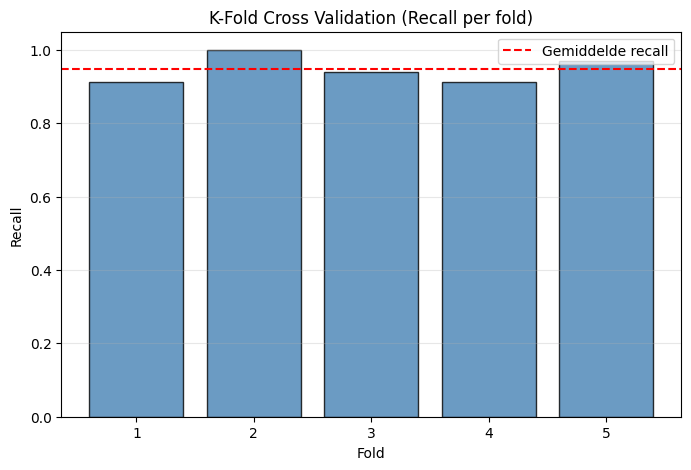

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# SVM model (zelfde als je pipeline, maar opnieuw gedefinieerd voor CV)
model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

# Stratified K-Fold → behoudt klassenverdeling in elke fold (belangrijk bij medical data)
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation op TRAINING set
scores = cross_val_score(
    model,
    X_train_sc,
    y_train,
    cv=kf,
    scoring="recall"   # belangrijk: focus op het vinden van malignant cases
)

print("=== K-Fold Cross Validation (Recall) ===")
print(f"Scores per fold: {scores}")
print(f"Gemiddelde recall: {np.mean(scores):.4f}")
print(f"Standaarddeviatie: {np.std(scores):.4f}")

# scores komt uit je K-fold cel
# (zorg dat je die cel eerst hebt uitgevoerd)
folds = np.arange(1, len(scores) + 1)

plt.figure(figsize=(8,5))

# Balkjes per fold
plt.bar(folds, scores, color="steelblue", edgecolor="black", alpha=0.8)

# Gemiddelde lijn
plt.axhline(np.mean(scores), color="red", linestyle="--", label="Gemiddelde recall")

plt.title("K-Fold Cross Validation (Recall per fold)")
plt.xlabel("Fold")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(folds)
plt.legend()
plt.grid(alpha=0.3, axis="y")

plt.show()

Welke waarde van k kies je en waarom?

(beantwoord als Markdown)

Lijkt het resultaat meer op de train of de testset?

(beantwoord als Markdown)

### Underfit/Overfit

Maak een underfit model (slechte prestaties op train en test) en een overfit model (veel betere prestaties op train vergeleken met test). Leg uit (via tekst en een of meer visualisaties) hoe je dit kan zien. 

Let op: je maakt hier expres slechte modellen om te zien hoe veel controle over het presteren van het model je kan krijgen en te leren wat de verschillende hyperparameters kunnen opleveren. 

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Het is gelukt om een underfit- een overfitmodel te maken en er wordt duidelijk uitgelegd waaraan je dat kan zien. De rol van de train en testset wordt duidelijk uitgelegd. De resultaten worden onderbouwd met goede vizualisaties."

UNDERFIT  vs  SVM (BALANCED)  vs  OVERFIT

Underfit (tree, depth=1)
  Accuracy train : 0.9297
  Accuracy test  : 0.8772
  Gap            : 0.0525
  Recall train   : 0.8706
  Recall test    : 0.7143

Gebalanceerd (SVM RBF)
  Accuracy train : 0.9868
  Accuracy test  : 0.9737
  Gap            : 0.0131
  Recall train   : 0.9647
  Recall test    : 0.9286

Overfit (tree, no limit)
  Accuracy train : 1.0000
  Accuracy test  : 0.9298
  Gap            : 0.0702
  Recall train   : 1.0000
  Recall test    : 0.9048


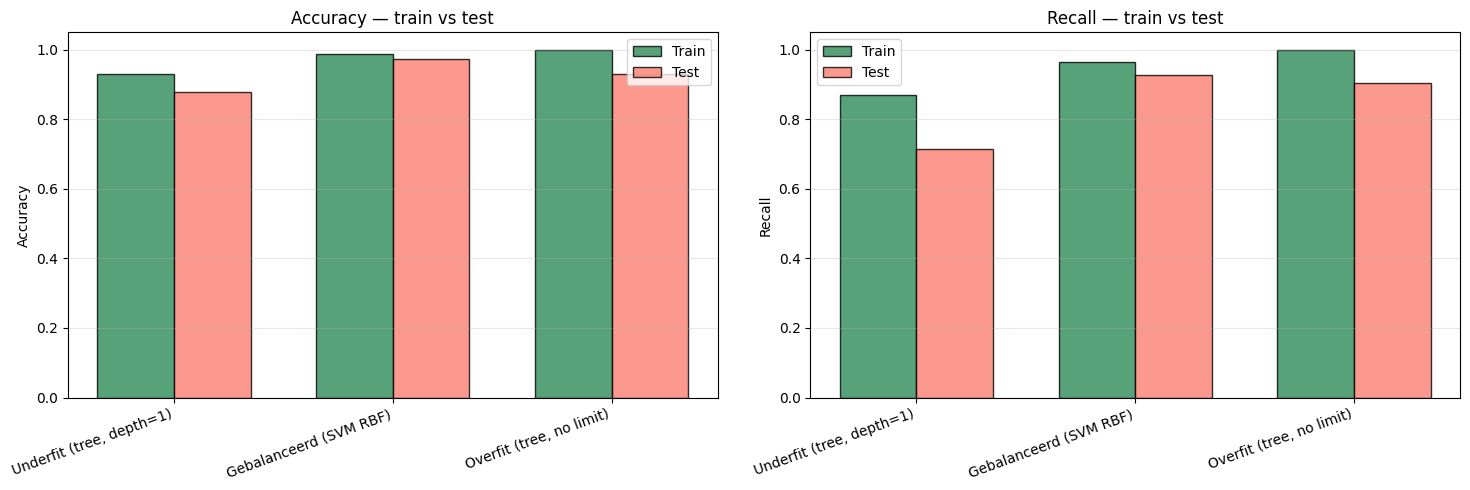

,Model,Accuracy train,Accuracy test,Recall train,Recall test,Gap
0,"Underfit (tree, depth=1)",0.929670,0.877193,0.870588,0.714286,0.052477
1,Gebalanceerd (SVM RBF),0.986813,0.973684,0.964706,0.928571,0.013129
2,"Overfit (tree, no limit)",1.000000,0.929825,1.000000,0.904762,0.070175


In [19]:
# === Underfit & Overfit modellen — SVM als gebalanceerd model ===

# Doel: laten zien hoe SVM en hyperparameters underfitting en overfitting beïnvloeden
# In  : X_train_sc, X_test_sc, y_train, y_test
# Uit : accuracy + recall + overfitting-gap + visualisaties

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# UNDERFIT MODEL
# =========================
# Te simpel model → kan geen complexe beslissingen leren
underfit_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

# =========================
# OVERFIT MODEL
# =========================
# Te complex model → leert trainingsdata uit het hoofd
overfit_model = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

# =========================
# GEBALANCEERD MODEL (SVM)
# =========================
# SVM met RBF kernel → goede balans tussen bias en variance
balanced_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

modellen = {
    "Underfit (tree, depth=1)": underfit_model,
    "Gebalanceerd (SVM RBF)": balanced_model,
    "Overfit (tree, no limit)": overfit_model,
}

resultaten = []

for naam, model in modellen.items():
    model.fit(X_train_sc, y_train)

    pred_train = model.predict(X_train_sc)
    pred_test  = model.predict(X_test_sc)

    resultaten.append({
        "Model": naam,

        # Accuracy
        "Accuracy train": accuracy_score(y_train, pred_train),
        "Accuracy test": accuracy_score(y_test, pred_test),

        # Recall (belangrijk in medical classification)
        "Recall train": recall_score(y_train, pred_train),
        "Recall test": recall_score(y_test, pred_test),

        # Overfitting indicator
        "Gap": accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test)
    })

resultaten_df = pd.DataFrame(resultaten)

print("=" * 70)
print("UNDERFIT  vs  SVM (BALANCED)  vs  OVERFIT")
print("=" * 70)

for r in resultaten:
    print(f"\n{r['Model']}")
    print(f"  Accuracy train : {r['Accuracy train']:.4f}")
    print(f"  Accuracy test  : {r['Accuracy test']:.4f}")
    print(f"  Gap            : {r['Gap']:.4f}")
    print(f"  Recall train   : {r['Recall train']:.4f}")
    print(f"  Recall test    : {r['Recall test']:.4f}")


# =========================
# VISUALISATIE
# =========================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(resultaten_df))
width = 0.35

# --- Accuracy ---
axes[0].bar(x - width/2, resultaten_df["Accuracy train"], width,
            color="seagreen", edgecolor="black", alpha=0.8, label="Train")

axes[0].bar(x + width/2, resultaten_df["Accuracy test"], width,
            color="salmon", edgecolor="black", alpha=0.8, label="Test")

axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy — train vs test")
axes[0].set_xticks(x)
axes[0].set_xticklabels(resultaten_df["Model"], rotation=20, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# --- Recall ---
axes[1].bar(x - width/2, resultaten_df["Recall train"], width,
            color="seagreen", edgecolor="black", alpha=0.8, label="Train")

axes[1].bar(x + width/2, resultaten_df["Recall test"], width,
            color="salmon", edgecolor="black", alpha=0.8, label="Test")

axes[1].set_ylabel("Recall")
axes[1].set_title("Recall — train vs test")
axes[1].set_xticks(x)
axes[1].set_xticklabels(resultaten_df["Model"], rotation=20, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

resultaten_df

(beantwoord als Markdown)

### RandomizedSearch

Pas RandomizedSearchCV() toe op je model in scikit-learn, hiermee kan je de beste waarde voor je hyperparameters vinden. RandomizedSearchCV is een andere methode dan GridSearch. Zie hier voor meer informatie: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

Let op: voor maximale punten moet je ook K-Fold Cross Validatie tegelijk gebruiken (wss in een pipeline...zie DataCamp).

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Er is RandomizedSearchCV() uitgevoerd en er wordt beargumenteerd waarom gekozen is voor bepaalde hyperparameters. Ook wordt benoemd welke hyperparameter uiteindelijk het beste lijkt te zijn en waarom, en er is besproken hoe k-foldcross validatie betrokken wordt in de RandomizedSearchCV()."

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Beste parameters: {'kernel': 'rbf', 'gamma': np.float64(0.008685113737513529), 'C': np.float64(184.20699693267164)}
Beste CV recall: 0.9588235294117646


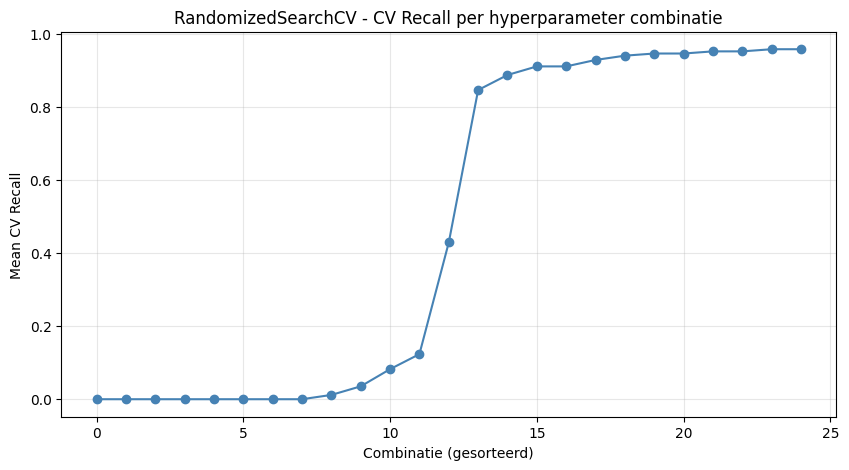

In [24]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# =========================
# MODEL + PARAMETER SPACE
# =========================
svm = SVC(random_state=42)

param_distributions = {
    "C": np.logspace(-3, 3, 50),
    "gamma": np.logspace(-4, 1, 50),
    "kernel": ["rbf"]
}

# =========================
# K-FOLD CROSS VALIDATION
# =========================
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================
# RANDOMIZED SEARCH
# =========================
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="recall",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_sc, y_train)

print("Beste parameters:", random_search.best_params_)
print("Beste CV recall:", random_search.best_score_)

# =========================
# VISUALISATIE
# =========================

results = random_search.cv_results_
mean_scores = results["mean_test_score"]

sorted_idx = np.argsort(mean_scores)
sorted_scores = mean_scores[sorted_idx]

plt.figure(figsize=(10,5))

plt.plot(sorted_scores, marker="o", linestyle="-", color="steelblue")

plt.title("RandomizedSearchCV - CV Recall per hyperparameter combinatie")
plt.xlabel("Combinatie (gesorteerd)")
plt.ylabel("Mean CV Recall")
plt.grid(alpha=0.3)

plt.show()

(beantwoord als Markdown)

### Definitief Model (Classificatie)

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Er worden uitspraken gedaan over hoe goed de modellen werken. De onderbouwing is duidelijk en logisch. Ook is beargumenteerd waarom het model niet under- en overfit. Daarnaast komt naar voren waarom bepaalde features wel en niet in het uiteindelijke model zitten."

Test het model met de beste parameters op de testset. Hoe goed is het model?

=== DEFINITIEF MODEL (SVM) ===
Train accuracy : 0.9956
Test accuracy  : 0.9561
Train recall   : 0.9882
Test recall    : 0.9286
Overfit gap    : 0.0395


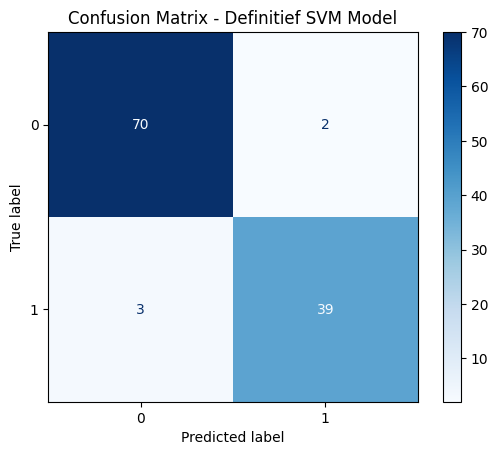

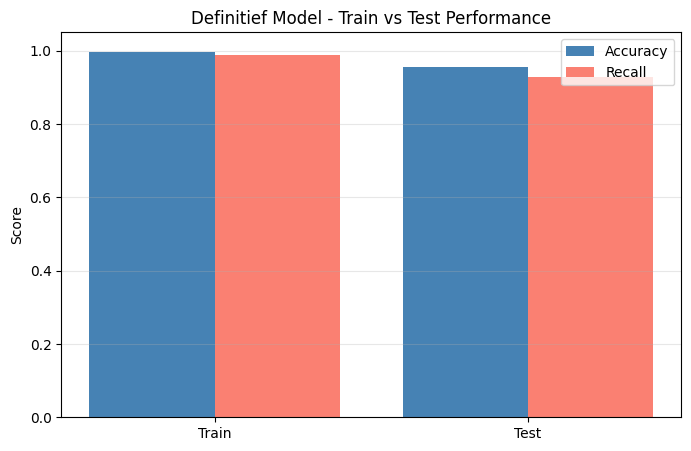

In [25]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# =========================
# BEST MODEL
# =========================
best_model = random_search.best_estimator_

best_model.fit(X_train_sc, y_train)

y_train_pred = best_model.predict(X_train_sc)
y_test_pred  = best_model.predict(X_test_sc)

# =========================
# METRICS
# =========================
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

train_recall = recall_score(y_train, y_train_pred)
test_recall  = recall_score(y_test, y_test_pred)

print("=== DEFINITIEF MODEL (SVM) ===")
print(f"Train accuracy : {train_acc:.4f}")
print(f"Test accuracy  : {test_acc:.4f}")
print(f"Train recall   : {train_recall:.4f}")
print(f"Test recall    : {test_recall:.4f}")
print(f"Overfit gap    : {train_acc - test_acc:.4f}")

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Definitief SVM Model")
plt.show()

# =========================
# VISUALISATIE: TRAIN vs TEST
# =========================
labels = ["Train", "Test"]
accuracy_vals = [train_acc, test_acc]
recall_vals = [train_recall, test_recall]

x = range(len(labels))

plt.figure(figsize=(8,5))

plt.bar(x, accuracy_vals, width=0.4, label="Accuracy", color="steelblue")
plt.bar([i + 0.4 for i in x], recall_vals, width=0.4, label="Recall", color="salmon")

plt.xticks([i + 0.2 for i in x], labels)
plt.ylim(0, 1.05)
plt.title("Definitief Model - Train vs Test Performance")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3, axis="y")

plt.show()

(beantwoord als Markdown)